# (Re-)Projection

Change the coordinate reference system ("project") of a raster, a vector or a matrix with coordinates.

## Settings

In [17]:
# Load packages
suppressPackageStartupMessages({
  library(terra)
})

# Parameters
param_crs <- "EPSG:28992"
param_from <- "EPSG:4326"
param_method <- "near"
param_mask <- 0
param_resolution <- NULL
param_raster <- NULL
param_out <- tempdir()

# Paths for examples
in_raster <- system.file("ex/elev.tif", package = "terra")
in_vector <- system.file("ex/lux.shp", package = "terra")
in_template <- ""

## Project vector

In [8]:
# GSTB project vector
# NaaVRE:
#  cell:
#   inputs:
#    - in_file: String
#   params:
#    - param_crs: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# Project vector
writeVector(x         = project(x       = vect(in_vector),
                                y       = param_crs,
                                partial = FALSE),
            filename  = paste0(param_out, "/projected_vector.gpkg"),
            overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "projected_vector.gpkg",
                  full.names = TRUE)

in_vector: 'character'

param_crs: 'character'

out: 'character'

In [9]:
print(vect(out))

 class       : SpatVector 
 geometry    : polygons 
 dimensions  : 12, 6  (geometries, attributes)
 extent      : 180650.6, 237158.2, 162002.3, 243635.1  (xmin, xmax, ymin, ymax)
 source      : projected_vector.gpkg
 coord. ref. : Amersfoort / RD New (EPSG:28992) 
 names       :  ID_1   NAME_1  ID_2   NAME_2  AREA       POP
 type        : <num>    <chr> <num>    <chr> <num>     <num>
 values      :     1 Diekirch     1 Clervaux   312 1.808e+04
                   1 Diekirch     2 Diekirch   218 3.254e+04
                   1 Diekirch     3  Redange   259 1.866e+04


## Project raster

In [22]:
# GSTB project raster
# NaaVRE:
#  cell:
#   inputs:
#    - in_raster: String
#    - in_template: String
#   params:
#    - param_raster: String
#    - param_crs: String
#    - param_method: String
#    - param_mask: Integer
#    - param_resolution: Float
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be (re-)projected
x <- rast(in_raster)

# Raster to define spatial characteristics
if(!is.null(param_crs) & (in_template == "")) {
  y <- param_crs
} else if(!is.null(in_template)) {
  y <- rast(in_template)
}

# Mask
if(param_mask == 1) {
  if_mask <- TRUE
} else {
  if_mask <- FALSE
}

# Raster spatial resolution
if(!is.null(param_resolution)) {
  param_res <- param_resolution
} else {
  param_res <- res(x)
}

# Project raster
project(x         = x,
        y         = y,
        method    = param_method,
        mask      = if_mask,
        res       = param_resolution,
        filename  = paste0(param_out, "/projected_raster.tif"),
        overwrite = TRUE)

# Output
out <- list.files(path = param_out,
                  pattern = "projected_raster.tif",
                  full.names = TRUE)

class       : SpatRaster 
dimensions  : 109, 75, 1  (nrow, ncol, nlyr)
resolution  : 772.1157, 772.1157  (x, y)
extent      : 180283.2, 238191.8, 160947.5, 245108.1  (xmin, xmax, ymin, ymax)
coord. ref. : Amersfoort / RD New (EPSG:28992) 
source      : projected_raster.tif 
name        : elevation 
min value   :       141 
max value   :       547 

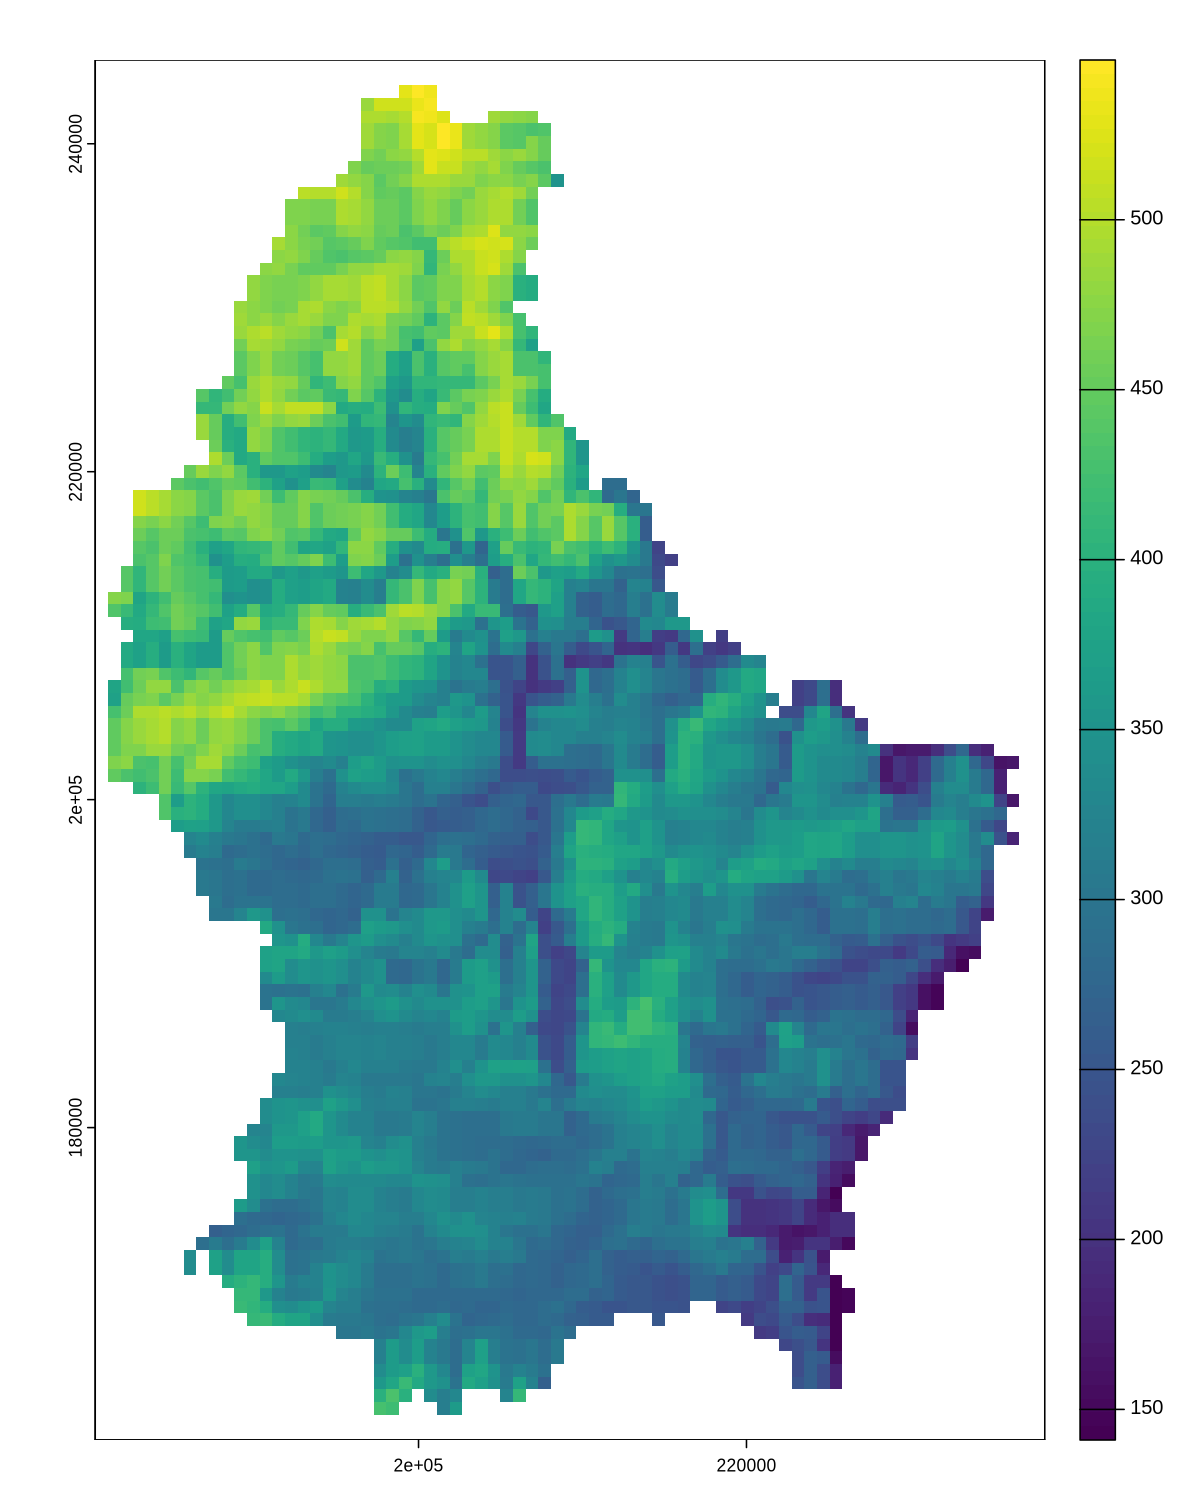

In [24]:
options(repr.plot.width = 8,
        repr.plot.height = 10,
        repr.plot.res = 150)
plot(rast(out))

## Project matrix with coordinates

In [6]:
# GSTB project matrix
#  cell:
#   inputs:
#    - in_matrix: String
#   params:
#    - param_crs: String
#    - param_from: String
#   outputs:
#    - out: String
#   dependencies:
#    - name: terra
# ...

# File path to be (re-)projected
x <- read.csv(in_matrix)

# Project matrix
v <- project(x       = x,
             from    = param_from,
             to      = param_crs)

# Save
writeVector(x         = v,
            filename  = paste0(param_out, "/projected_matrix.gpkg"),
            overwrite = TRUE)

ERROR: Error: object 'in_matrix' not found
